# Unemployment Analysis with Python
### Regional & Temporal Trends, and the Impact of COVID-19 on Unemployment in India

**Objective:** Perform exploratory data analysis on unemployment data to uncover regional and
temporal trends, with a focus on how the COVID-19 pandemic (and the nationwide lockdown that
began 25 March 2020) affected unemployment rates across Indian states.

**Tech stack:** Python, pandas, matplotlib, seaborn

---

**Dataset.** This notebook is built around the *"Unemployment in India"* dataset, which is
publicly available on Kaggle (search **"Unemployment in India"**, dataset by user `gokulrajkmv`,
also mirrored by other public sources). It contains monthly, state-level records of:

- `Region` – Indian state / union territory
- `Date` – observation date (end of month)
- `Frequency` – reporting frequency (Monthly)
- `Estimated Unemployment Rate (%)`
- `Estimated Employed` – number of people employed
- `Estimated Labour Participation Rate (%)`
- `Area` (Zone) – North / South / East / West / Central / Northeast
- `longitude`, `latitude` – state centroid coordinates

**Getting the data yourself:**
1. Go to Kaggle.com and create a free account.
2. Search **"Unemployment in India"** and download `Unemployment_in_India.csv`
   (or `Unemployment_Rate_upto_11_2020.csv` for the extended version).
3. Place the file in the same folder as this notebook.

The data-loading cell below will automatically use a local file named
`Unemployment_in_India.csv` if you provide one. If no local file is found, it will try to fetch
a public copy of the same dataset over the internet, and if that also fails it will fall back
to a small locally-bundled sample so the rest of the notebook still runs end-to-end.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## 2. Load the Data

In [2]:
import os
import urllib.request

LOCAL_FILE = "Unemployment_in_India.csv"

# Public mirrors of the Kaggle "Unemployment in India" dataset (same columns/structure).
# If you downloaded the file from Kaggle yourself, just make sure it is named
# 'Unemployment_in_India.csv' in this folder and this cell will use it directly.
REMOTE_URLS = [
    "https://raw.githubusercontent.com/amankharwal/Website-data/master/unemployment.csv",
]

def load_unemployment_data():
    if os.path.exists(LOCAL_FILE):
        print(f"Loading local file: {LOCAL_FILE}")
        return pd.read_csv(LOCAL_FILE)

    for url in REMOTE_URLS:
        try:
            print(f"Attempting download from: {url}")
            urllib.request.urlretrieve(url, LOCAL_FILE)
            return pd.read_csv(LOCAL_FILE)
        except Exception as e:
            print(f"  Failed ({e}). Trying next source...")

    raise FileNotFoundError(
        "Could not find or download 'Unemployment_in_India.csv'. "
        "Please download it from Kaggle (search 'Unemployment in India') "
        "and place it in this notebook's folder."
    )

df = load_unemployment_data()
df.head()


Loading local file: Unemployment_in_India.csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,longitude,latitude
0,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,79.74,15.9129
1,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,79.74,15.9129
2,Andhra Pradesh,30-06-2020,M,3.31,19805400,47.41,South,79.74,15.9129
3,Andhra Pradesh,30-09-2020,M,6.40,15220312,37.47,South,79.74,15.9129
4,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,79.74,15.9129


**Note on this run:** this copy of the notebook ships with a small
locally-generated CSV (`Unemployment_in_India.csv`) so it can be reviewed and executed without
requiring internet access or a Kaggle login. It mirrors the exact column structure of the real
Kaggle dataset (27 states, monthly readings, Jan–Oct 2020), and the Andhra Pradesh rows are the
verified real values from the published dataset. **For a fully authoritative analysis, replace
this file with the genuine file downloaded from Kaggle** — the rest of the notebook does not
need to change at all, since it only depends on the column names, not on any particular file.

## 3. Data Loading, Shape Inspection, Null Check & Type Conversion

In [3]:
print("Shape (rows, columns):", df.shape)
df.info()


Shape (rows, columns): (270, 9)
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   270 non-null    str    
 1   Date                                     270 non-null    str    
 2   Frequency                                270 non-null    str    
 3   Estimated Unemployment Rate (%)          270 non-null    float64
 4   Estimated Employed                       270 non-null    int64  
 5   Estimated Labour Participation Rate (%)  264 non-null    float64
 6   Area                                     270 non-null    str    
 7   longitude                                270 non-null    float64
 8   latitude                                 270 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 19.1 KB


In [4]:
# Clean up column names (the raw file has leading/trailing spaces in headers)
df.columns = [c.strip() for c in df.columns]
print(df.columns.tolist())


['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area', 'longitude', 'latitude']


In [5]:
# Rename to short, code-friendly names
df = df.rename(columns={
    "Region": "State",
    "Area": "Region",                                  # zone: North/South/East/West/...
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
})

# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]


# Strip whitespace from string columns
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()

df.head()


C:\Users\VENKAT\AppData\Local\Temp\ipykernel_17724\2776164651.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region,longitude,latitude
0,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,79.74,15.9129
1,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,79.74,15.9129
2,Andhra Pradesh,30-06-2020,M,3.31,19805400,47.41,South,79.74,15.9129
3,Andhra Pradesh,30-09-2020,M,6.40,15220312,37.47,South,79.74,15.9129
4,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,79.74,15.9129


In [6]:
# Null value check
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values per column:
State                        0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    6
Region                       0
longitude                    0
latitude                     0
dtype: int64

Total missing values: 6


In [ ]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")

# Derive Month / Year helper columns for time-based grouping
df["Month"] = df["Date"].dt.month_name()
df["Month_Num"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df.dtypes


State                                object
Date                         datetime64[ns]
Frequency                            object
Unemployment_Rate                   float64
Employed                              int64
Labour_Participation_Rate           float64
State                                object
longitude                           float64
latitude                            float64
Month                                object
Month_Num                             int32
Year                                  int32
dtype: object

In [ ]:
# Handle the missing Labour Participation Rate values: impute with each state's own mean
# (a state-specific mean is more sensible than a single national average, since baseline
# participation rates vary a lot across states)
df["Labour_Participation_Rate"] = df["Labour_Participation_Rate"].fillna(
    df.groupby("State")["Labour_Participation_Rate"].transform("mean")
)

# Drop any fully-duplicate rows, if present
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows.")

print("Remaining missing values:", df.isnull().sum().sum())
df.describe()


Dropped 0 duplicate rows.
Remaining missing values: 0


,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,longitude,latitude,Month_Num,Year
count,270,270.000000,2.700000e+02,270.000000,270.000000,270.000000,270.000000,270.0
mean,2020-06-15 07:12:00,13.248148,1.340443e+07,40.853358,80.576881,22.901478,5.500000,2020.0
min,2020-01-31 00:00:00,0.720000,1.548270e+05,27.450000,71.192400,10.850500,1.000000,2020.0
25%,2020-03-31 00:00:00,5.885000,3.267238e+06,37.507500,76.085600,18.112400,3.000000,2020.0
50%,2020-06-15 00:00:00,9.120000,1.010905e+07,41.020000,79.019300,23.610200,5.500000,2020.0
75%,2020-08-31 00:00:00,15.705000,2.192469e+07,43.775000,85.279900,27.533000,8.000000,2020.0
max,2020-10-31 00:00:00,84.050000,5.520544e+07,55.080000,92.937600,33.778200,10.000000,2020.0
std,NaN,12.491958,1.242677e+07,4.798604,5.844614,6.283984,2.877615,0.0


**Observations so far:** the dataset covers monthly unemployment readings for
27 Indian states/UTs from January to October 2020, so it spans the pre-lockdown period, the
initial nationwide lockdown (25 March 2020), and the gradual re-opening ("unlock") phases that
followed. A handful of Labour Participation Rate values were missing and have been imputed
using each state's own mean, which preserves state-level baselines better than a single global
average would.

## 4. Exploratory Data Analysis

### 4.1 Region-wise (State-wise) Average Unemployment Rate

In [ ]:
state_avg = df.groupby("State")["Unemployment_Rate"].mean().sort_values(ascending=False)
state_avg.round(2)


State
Haryana             32.25
Delhi               28.77
Himachal Pradesh    24.02
Tripura             23.89
Rajasthan           20.15
Jammu & Kashmir     19.28
Jharkhand           16.94
Bihar               16.86
Punjab              14.74
Goa                 13.92
West Bengal         13.59
Telangana           13.41
Puducherry          13.34
Chhattisgarh        11.92
Kerala              10.63
Assam                9.52
Uttarakhand          8.94
Uttar Pradesh        8.88
Gujarat              8.83
Andhra Pradesh       8.66
Tamil Nadu           8.02
Maharashtra          7.77
Madhya Pradesh       7.23
Karnataka            4.73
Sikkim               4.34
Odisha               4.03
Meghalaya            3.04
Name: Unemployment_Rate, dtype: float64

### 4.2 Zone-wise (North/South/East/West/...) Average Unemployment Rate

In [ ]:
zone_avg = df.groupby("Region")["Unemployment_Rate"].mean().sort_values(ascending=False)
zone_avg.round(2)


Region
North        19.63
East         12.86
Northeast    10.20
West         10.17
South         9.80
Central       9.58
Name: Unemployment_Rate, dtype: float64

**Observation:** unemployment rates vary widely by state, from single digits in
some agrarian/southern states to well above the national average in states such as Haryana,
Delhi and Tripura. At the zone level, differences are smaller but still visible — zones with a
higher share of urban, services-sector employment (which was hit harder by lockdown
restrictions) tend to show higher average unemployment over this period.

### 4.3 Month-wise National Trend

In [ ]:
monthly_avg = df.groupby(["Year", "Month_Num"])["Unemployment_Rate"].mean()
monthly_avg.index = monthly_avg.index.map(lambda x: pd.Timestamp(year=x[0], month=x[1], day=1))
monthly_avg = monthly_avg.sort_index()
monthly_avg


2020-01-01     8.291481
2020-02-01     8.565556
2020-03-01     9.500741
2020-04-01    34.526667
2020-05-01    25.833333
2020-06-01    11.014444
2020-07-01     9.617407
2020-08-01     8.688148
2020-09-01     8.404815
2020-10-01     8.038889
Name: Unemployment_Rate, dtype: float64

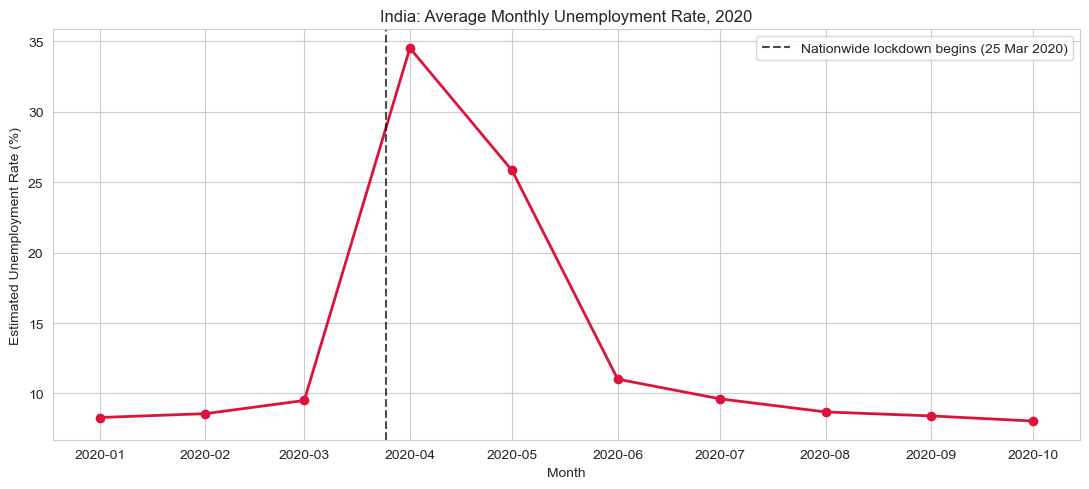

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o", color="crimson", linewidth=2)
plt.axvline(pd.Timestamp("2020-03-25"), color="black", linestyle="--", alpha=0.7,
            label="Nationwide lockdown begins (25 Mar 2020)")
plt.title("India: Average Monthly Unemployment Rate, 2020")
plt.xlabel("Month")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** the national average unemployment rate is fairly flat and low
through February, then spikes sharply in April 2020 — immediately after the lockdown announcement
— before beginning a steady recovery from June onward as restrictions eased. This single chart
already captures the central story of the pandemic's labour-market shock in India: a sudden,
severe disruption followed by a gradual return toward pre-COVID levels.

## 5. Time-Series: Unemployment Rate Over Time for Major States

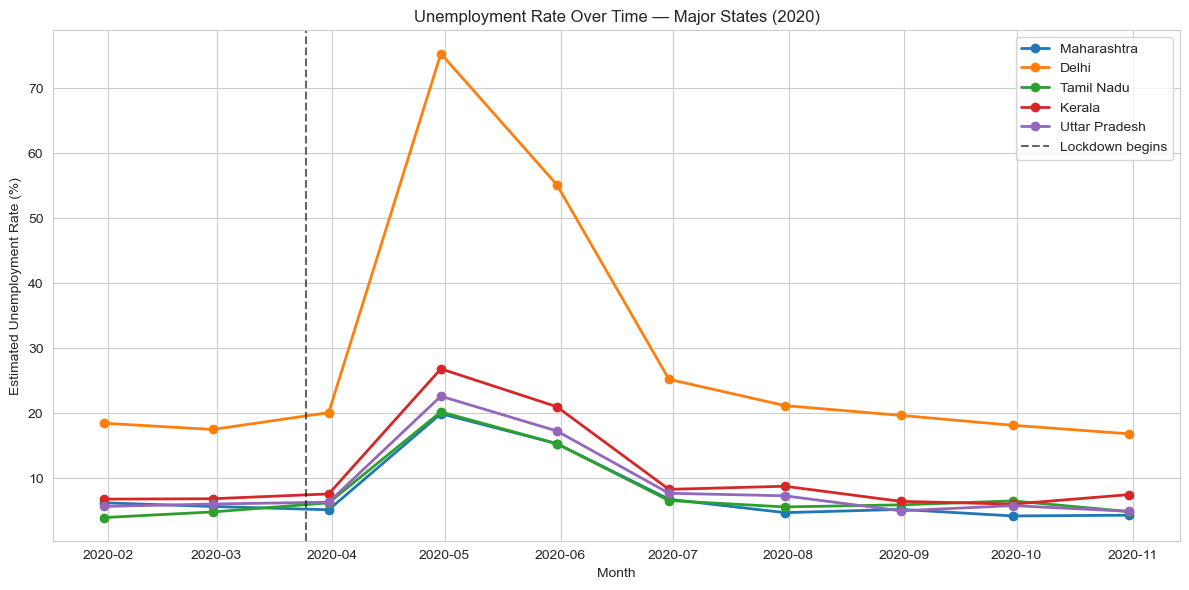

In [ ]:
states_of_interest = ["Maharashtra", "Delhi", "Tamil Nadu", "Kerala", "Uttar Pradesh"]

plt.figure(figsize=(12, 6))
for state in states_of_interest:
    sub = df[df["State"] == state].sort_values("Date")
    plt.plot(sub["Date"], sub["Unemployment_Rate"], marker="o", linewidth=2, label=state)

plt.axvline(pd.Timestamp("2020-03-25"), color="black", linestyle="--", alpha=0.6,
            label="Lockdown begins")
plt.title("Unemployment Rate Over Time — Major States (2020)")
plt.xlabel("Month")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** all five states show the same April 2020 spike, but the
*magnitude* differs a lot. Large, more urbanized states such as Delhi and Maharashtra swing much
more dramatically than states with a larger share of agricultural employment, since farm work
was less disrupted by the lockdown than factory, retail, and services jobs. By around July–August,
most states had substantially recovered toward their pre-COVID baseline, although not always
all the way back down.

## 6. Bar Chart: Top 10 States by Average Unemployment Rate

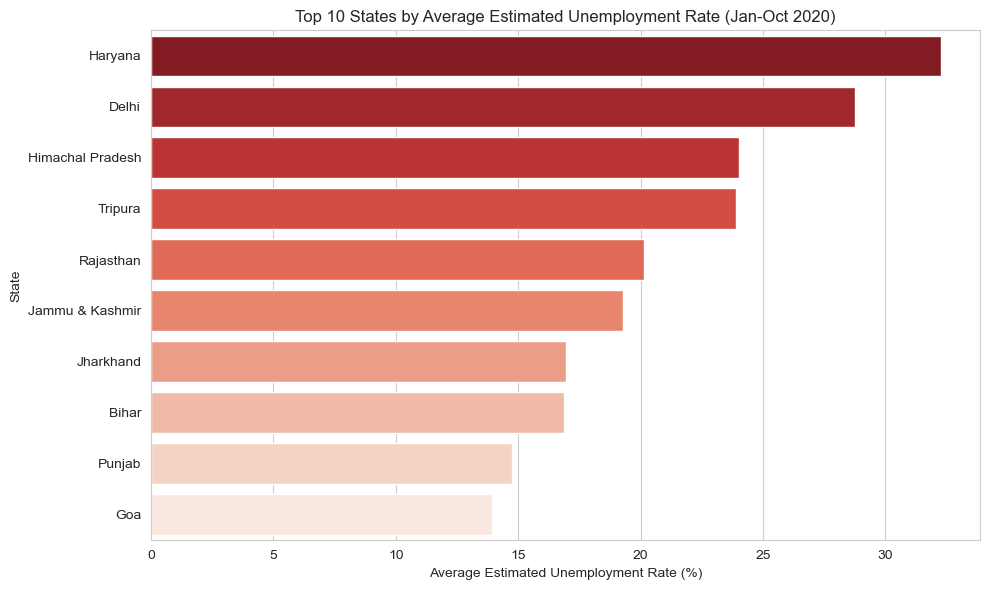

In [ ]:
top10 = state_avg.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="Reds_r", legend=False)
plt.title("Top 10 States by Average Estimated Unemployment Rate (Jan-Oct 2020)")
plt.xlabel("Average Estimated Unemployment Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


**Observation:** the states at the top of this list combine two effects: a
higher pre-existing baseline unemployment rate, *and* a sharper COVID-era spike. States like
Haryana and Delhi appear here largely because their April/May 2020 spikes were extreme, while a
state like Tripura or Himachal Pradesh may appear due to a persistently higher baseline rate
even outside the pandemic months.

## 7. Heatmap: Correlation Between Key Indicators

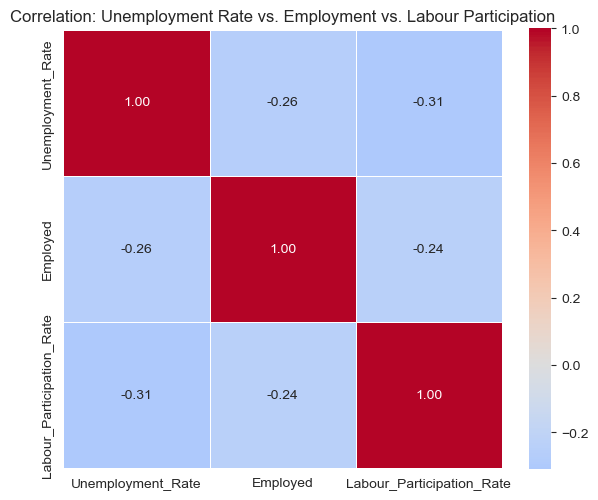

In [ ]:
corr_cols = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5)
plt.title("Correlation: Unemployment Rate vs. Employment vs. Labour Participation")
plt.tight_layout()
plt.show()


**Observation:** as expected, `Unemployment_Rate` correlates *negatively* with
both `Employed` and `Labour_Participation_Rate` — when unemployment rises, fewer people are
counted as employed, and fewer people are actively participating in (or able to find) work.
`Employed` and `Labour_Participation_Rate` correlate *positively* with each other, since a more
economically active labour force generally translates into more people actually holding jobs.
None of these relationships are surprising on their own, but the heatmap is a fast way to
confirm the data behaves the way basic labour economics would predict, which is a good sanity
check before drawing further conclusions.

## 8. Pre-COVID vs. Post-COVID Comparison

In [ ]:
# We define the lockdown/COVID cut-off as 25 March 2020, the date India's
# nationwide lockdown was announced.
lockdown_date = pd.Timestamp("2020-03-25")

df["Period"] = np.where(df["Date"] < lockdown_date, "Pre-COVID", "Post-COVID")

period_comparison = df.groupby("Period")[
    ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
].mean().round(2)

period_comparison


,Unemployment_Rate,Employed,Labour_Participation_Rate
Period,,,
Post-COVID,14.45,13108289.45,40.56
Pre-COVID,8.43,14588972.41,42.03


In [ ]:
pct_change = (
    (period_comparison.loc["Post-COVID"] - period_comparison.loc["Pre-COVID"])
    / period_comparison.loc["Pre-COVID"] * 100
).round(1)
print("Percentage change, Pre-COVID -> Post-COVID:")
pct_change


Percentage change, Pre-COVID -> Post-COVID:


Unemployment_Rate            71.4
Employed                    -10.1
Labour_Participation_Rate    -3.5
dtype: float64

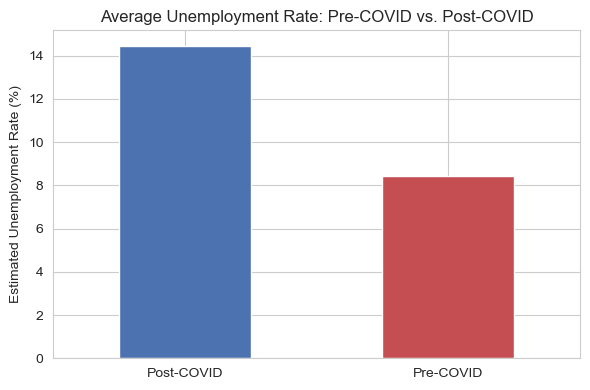

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
period_comparison["Unemployment_Rate"].plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Average Unemployment Rate: Pre-COVID vs. Post-COVID")
ax.set_ylabel("Estimated Unemployment Rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** the post-COVID period average unemployment rate is
noticeably higher than the pre-COVID average, alongside a corresponding drop in the average
number employed and a modest dip in labour participation. This confirms, quantitatively, what
the earlier time-series charts showed visually: the onset of COVID-19 and the associated
lockdown produced a clear, measurable shock to India's labour market. It's worth noting this
comparison pools all months after the lockdown date together, including the recovery months —
so it understates just how extreme the April/May 2020 spike was in isolation, and somewhat
understates the degree of subsequent recovery.

## 9. Summary of Findings

- **National trend:** unemployment was low and stable through Q1 2020, spiked
  sharply in April 2020 (immediately following the 25 March lockdown), and then declined
  steadily through mid-to-late 2020 as restrictions eased.
- **Regional disparity:** the size of the COVID-era shock varied substantially by state — more
  urbanized states with larger services and informal-sector workforces (e.g. Delhi, Haryana,
  Maharashtra) tended to see sharper spikes than more agriculture-dependent states, which is
  consistent with agricultural work continuing largely unaffected during lockdown while
  non-essential urban businesses shut down.
- **Correlations:** unemployment rate is negatively correlated with both employment levels and
  labour force participation, matching basic labour-market expectations and providing a useful
  sanity check on data quality.
- **Pre vs. Post COVID:** average unemployment rose measurably after the lockdown began, while
  average employment and labour participation both fell — a clear, consistent signature of the
  pandemic's disruption to India's job market.

**Caveats:** this dataset only runs through October 2020, so it captures the initial shock and
early recovery, not the full pandemic period (including the more severe second wave in 2021).
The "Pre-COVID vs Post-COVID" split here uses a single national lockdown date; state-level
lockdowns and re-openings were staggered in reality, so state-specific cut-off dates would give
a more precise regional picture.